# 04 — Critical Evaluation of PCA (Task 7)

Brief section 8. Take a balanced position: PCA is not worthwhile on the ~10-feature
customer table (interpretability matters, LASSO/elastic net already handle
correlated predictors), but is useful on the sparse customer x product matrix to
reveal latent buying patterns.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

clean = pd.read_csv('../data/processed/invoice_lines_clean.csv', parse_dates=['InvoiceDate'])
customers = pd.read_csv('../data/processed/customer_table.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## PCA on the customer-level feature table (demonstrate why it's not worthwhile)

In [3]:
FEATURES = ['Recency', 'TenureDays', 'CancellationRate',
            'log_Frequency', 'log_Monetary', 'log_DistinctProducts', 'log_AvgBasketValue',
            'IsUK', 'AcquiredInQ4']

df = customers.copy()
for col in ['Frequency', 'Monetary', 'DistinctProducts', 'AvgBasketValue']:
    df[f'log_{col}'] = np.log1p(df[col])

X = df[FEATURES]
Xs = StandardScaler().fit_transform(X)

pca = PCA().fit(Xs)

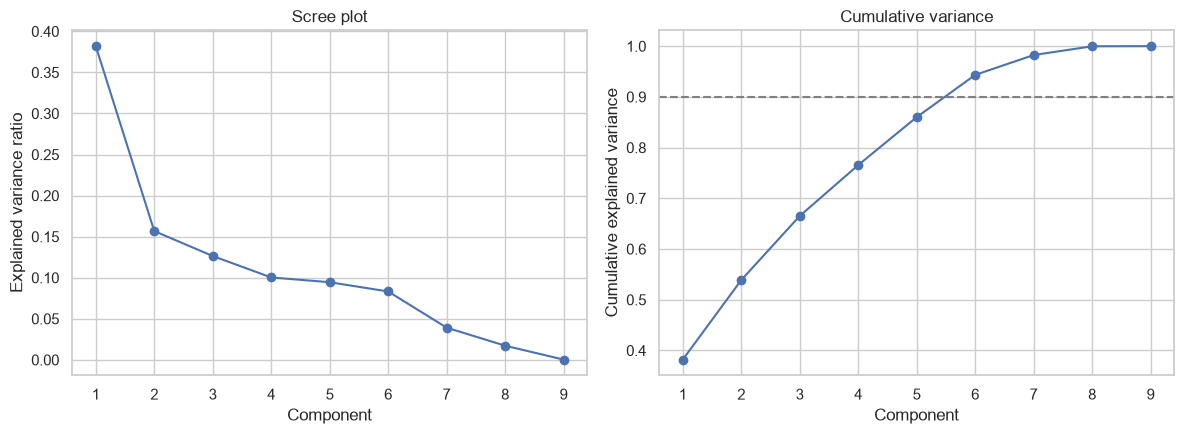

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(range(1, len(FEATURES)+1), pca.explained_variance_ratio_, marker='o')
ax[0].set_xlabel('Component'); ax[0].set_ylabel('Explained variance ratio'); ax[0].set_title('Scree plot')

ax[1].plot(range(1, len(FEATURES)+1), np.cumsum(pca.explained_variance_ratio_), marker='o')
ax[1].axhline(0.9, ls='--', c='grey')
ax[1].set_xlabel('Component'); ax[1].set_ylabel('Cumulative explained variance'); ax[1].set_title('Cumulative variance')
plt.tight_layout(); plt.savefig('../reports/figures/pca_scree_customer.png', dpi=150)

In [5]:
n90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1)
print(f'{n90} of {len(FEATURES)} components needed to reach 90% variance')

6 of 9 components needed to reach 90% variance


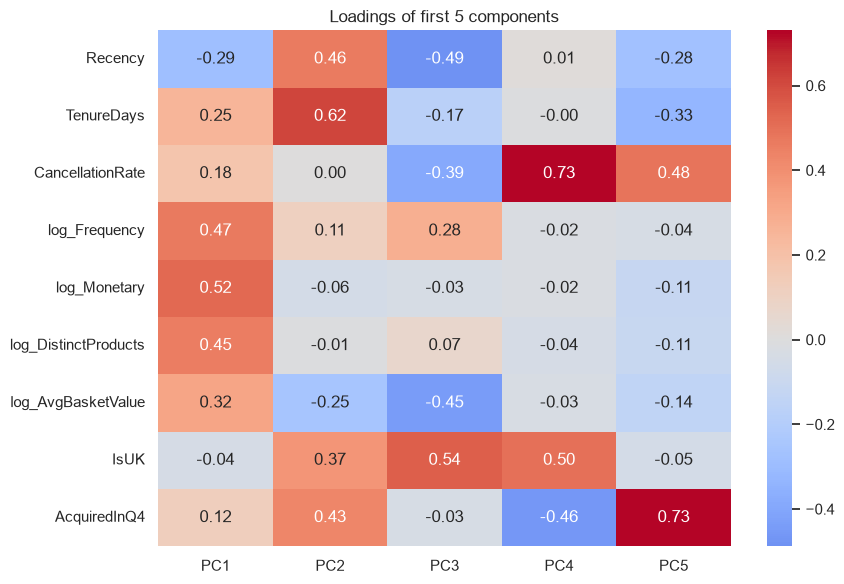

In [6]:
loadings = pd.DataFrame(pca.components_.T, index=FEATURES,
                         columns=[f'PC{i+1}' for i in range(len(FEATURES))])
plt.figure(figsize=(9, 6))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Loadings of first 5 components'); plt.tight_layout()

## Customer x Product purchase matrix

In [7]:
sales = clean[(~clean['IsCancellation']) & (clean['Quantity'] > 0)].copy()

# Purchase count matrix (could also use LineRevenue for a spend-weighted version)
CUTOFF_DATE = '2011-09-09'

sales_pre = clean[(~clean['IsCancellation']) & (clean['Quantity'] > 0)
                   & (clean['InvoiceDate'] < CUTOFF_DATE)].copy()
pivot = sales_pre.pivot_table(index='CustomerID', columns='StockCode',
                               values='Quantity', aggfunc='sum', fill_value=0)
print(pivot.shape, '| sparsity:', (pivot == 0).mean().mean().round(4))

(5253, 4445) | sparsity: 0.9832


In [8]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

X_sparse = csr_matrix(pivot.values)
svd = TruncatedSVD(n_components=20, random_state=42).fit(X_sparse)
print('Variance explained by 20 components:', svd.explained_variance_ratio_.sum().round(3))

Variance explained by 20 components: 0.867


In [9]:
products = pd.DataFrame(svd.components_.T, index=pivot.columns,
                         columns=[f'SVD{i+1}' for i in range(20)])

# top products (by description) driving the first few components
desc_lookup = clean.drop_duplicates('StockCode').set_index('StockCode')['Description']
for comp in ['SVD1', 'SVD2', 'SVD3']:
    top = products[comp].abs().nlargest(10).index
    print(f'\n{comp} top products:')
    print(desc_lookup.reindex(top))


SVD1 top products:
StockCode
37410     BLACK AND WHITE PAISLEY FLOWER MUG
21091            SET/6 WOODLAND PAPER PLATES
21099            SET/6 STRAWBERRY PAPER CUPS
21085              SET/6 WOODLAND PAPER CUPS
21092          SET/6 STRAWBERRY PAPER PLATES
85220        SMALL FAIRY CAKE FRIDGE MAGNETS
20993                   JAZZ HEARTS MEMO PAD
20991          JAZZ HEARTS MAGNETIC MEMO PAD
47503E             ASS FLORAL PRINT SCISSORS
16044               POP-ART FLUORESCENT PENS
Name: Description, dtype: str

SVD2 top products:
StockCode
21982               PACK OF 12 SUKI TISSUES 
21981           PACK OF 12 WOODLAND TISSUES 
21984       PACK OF 12 PINK PAISLEY TISSUES 
21980         PACK OF 12 RED SPOTTY TISSUES 
21985      PACK OF 12 HEARTS DESIGN TISSUES 
17003                    BROCADE RING PURSE 
21967               PACK OF 12 SKULL TISSUES
21986          PACK OF 12 PINK SPOT TISSUES 
84347    ROTATING SILVER ANGELS T-LIGHT HLDR
22616             PACK OF 12 LONDON TISSUES 
Name: Desc

In [ ]:
#SVD1: paper party/tableware sets (plates, cups, mugs) — a "party supplies" buyer pattern.
#SVD2 and SVD3: both dominated by tissue packs and jumbo bags — these two components overlap heavily rather than capturing distinct patterns, likely bulk/wholesale-style buyers.

## Does it help the predictive model?

In [10]:
train2, test2 = train_test_split(df, test_size=0.25, random_state=42, stratify=df['Repurchase'])

pivot_tr = pivot.reindex(train2['CustomerID']).fillna(0)
pivot_te = pivot.reindex(test2['CustomerID']).fillna(0)

svd_pred = TruncatedSVD(n_components=20, random_state=42).fit(csr_matrix(pivot_tr.values))

scores_tr = pd.DataFrame(svd_pred.transform(csr_matrix(pivot_tr.values)), index=train2['CustomerID'],
                          columns=[f'SVD{i+1}' for i in range(20)])
scores_te = pd.DataFrame(svd_pred.transform(csr_matrix(pivot_te.values)), index=test2['CustomerID'],
                          columns=[f'SVD{i+1}' for i in range(20)])

EXTRA = FEATURES + [f'SVD{i+1}' for i in range(20)]

train2 = train2.merge(scores_tr, left_on='CustomerID', right_index=True, how='left').fillna(0)
test2  = test2.merge(scores_te,  left_on='CustomerID', right_index=True, how='left').fillna(0)

scaler2 = StandardScaler().fit(train2[EXTRA])
Xtr2 = sm.add_constant(pd.DataFrame(scaler2.transform(train2[EXTRA]), columns=EXTRA, index=train2.index))
Xte2 = sm.add_constant(pd.DataFrame(scaler2.transform(test2[EXTRA]), columns=EXTRA, index=test2.index))

logit2 = sm.Logit(train2['Repurchase'], Xtr2).fit(disp=0)
auc_with_svd = roc_auc_score(test2['Repurchase'], logit2.predict(Xte2))
print('AUC with SVD features:', round(auc_with_svd, 4), 'vs baseline 0.809-0.810 from notebook 03')

AUC with SVD features: 0.8065 vs baseline 0.809-0.810 from notebook 03


## Conclusion

_Write up: where PCA helps, where it doesn't, and why — tie back to Jolliffe & Cadima (2016)._

**Customer table:** PCA needs 6 of the 9 features to reach 90% variance — almost no
compression. Not worthwhile: elastic net (notebook 03) already handles the collinearity
(log_Monetary/log_Frequency/log_AvgBasketValue) while keeping features named and
interpretable as odds ratios.

**Product matrix:** genuinely high-dimensional and sparse (5,253 x 4,445, 98.3% sparse).
20 SVD components explain 86.7% of variance. Components are interpretable as buying
patterns (party supplies vs. bulk tissue/bag buyers), though SVD2/SVD3 overlap rather
than separating cleanly.

**Predictive value:** adding the SVD components dropped AUC slightly (0.8065 vs.
0.809-0.810 baseline) once time-cutoff and train/test leakage were removed — the latent
patterns are interpretable and worth reporting on their own, but don't improve repurchase
prediction beyond the existing RFM features.

This matches Jolliffe & Cadima (2016): dimensionality reduction pays off when dimensionality
itself is the problem (sparse, high-cardinality data), not when a handful of already-meaningful
features are simply correlated.